# Tutorial
This tutorial shows the basic steps of using SEP to detect objects in an image and perform some basic aperture photonometry.

In [1]:
import numpy as np
import sep

In [2]:
# additional setup for reading the test image and displaying plots
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10.,8.]

First, we'll read an example image from a FITS file and display it, just to show what we're dealing with. The example is just 256 x 256 pixels.

In [3]:
# read image into standard 2D numpy array
# HDU (Header Data Unit) holds several lists, with index[0] being the primary HDU 
hdul = fits.open('example.fits')
data = hdul[0].data 

ESO-LOG 00:00:00> DATE         = '1992-10-26'  / Mon Oct 26, 1992                [astropy.io.fits.card]
ESO-LOG 03:04:08>-START EXPO EMMI RED          / Start exp. on EMMI Red CC       [astropy.io.fits.card]
ESO-LOG 03:04:09> EXPO EMMI RED NO = 24887     / Exp. num. on EMMI Red CCD       [astropy.io.fits.card]
ESO-LOG 03:10:52>-STOP EXPO EMMI RED           / Stop exp. on EMMI Red CCD       [astropy.io.fits.card]


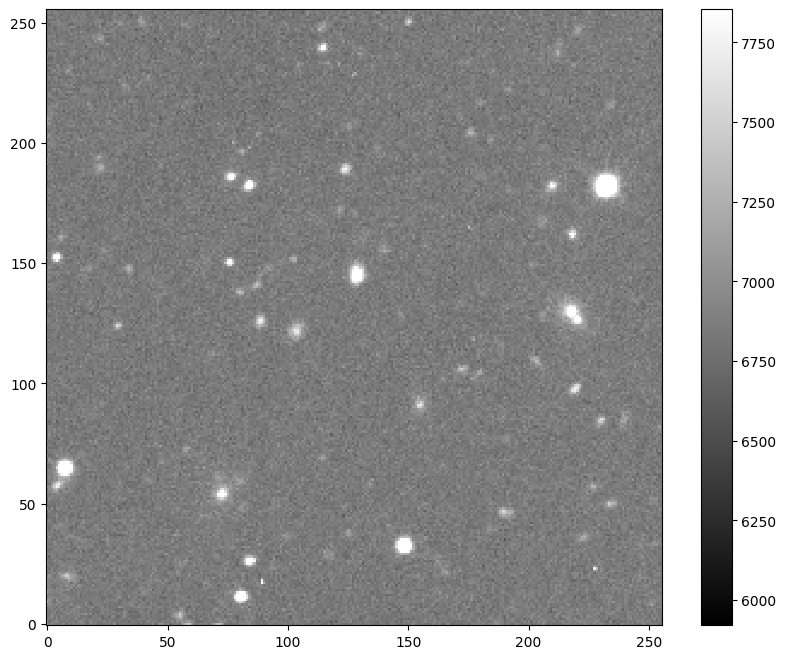

In [4]:
# show the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.savefig('FITS-example.png', bbox_inches='tight', facecolor='white')

## Background subtraction
Most optical/IR data nust be background subtracted before sources can be detected. In SEP, background estimation and source detection are two separate steps.

In [5]:
# measure a spatially varying background on the image
bkg = sep.Background(data)

There are various options for controlling the box size used in estimating the background. It is also possible to mask pixels. For example:

bkg = sep.Background(data, mask=mask, bw=64, bh=64, fw=3, fh=3)

This returns a Background object that holds information on the spatially varying background and spatially varying background noise level. We can now do various things with this Background object:

In [6]:
# get a 'global' mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

6852.04931640625
65.46174621582031


In [7]:
# evaluate background as 2D array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

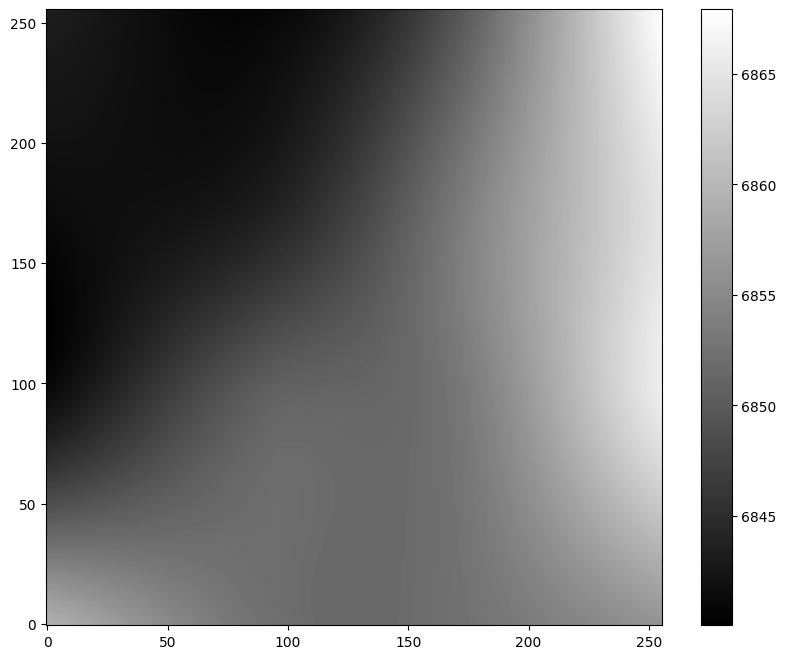

In [8]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar()
plt.savefig('FITS-example-background.png', bbox_inches='tight', facecolor='white')

In [9]:
# evaluate the background noise as 2D array, same size as original image
bkg_rms = bkg.rms()

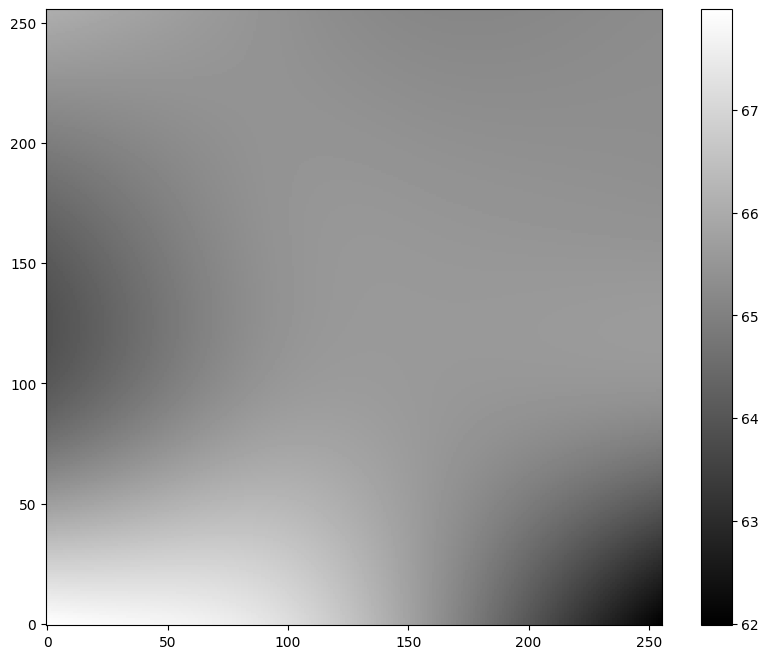

In [10]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar()
plt.savefig('FITS-example-background-noise.png', bbox_inches='tight', facecolor='white')

In [11]:
# subtract the background
data_sub = data - bkg
# bkg.subfrom(data) # can subtract the background from the data array in-place

### Warning:
If the data array is not background-subtracted or the threshold is too low, you will tend to get one giant object when you run object detection using sep.extract. Or, more likely, an exception will be raised due to exceeding the internal memory constraints of the sep.extract function.

## Object detection
Now that we've subtracted the background, we can run object detection on the background-subtracted data. You can see the background noise level is pretty flat. So here we're setting the detection threshold to be a constant value of 1.5 sigma where sigma is the global background RMS.

In [12]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

object is a NumPy structured array with many fields.

In [13]:
# how many objects were detected
len(objects)

69

objects['x'] and objects['y'] will give the centroid coordinates of the objects. Just to check where the detected objects are, we'll over-plot the object coordinates with some basic shape parameters on the image:

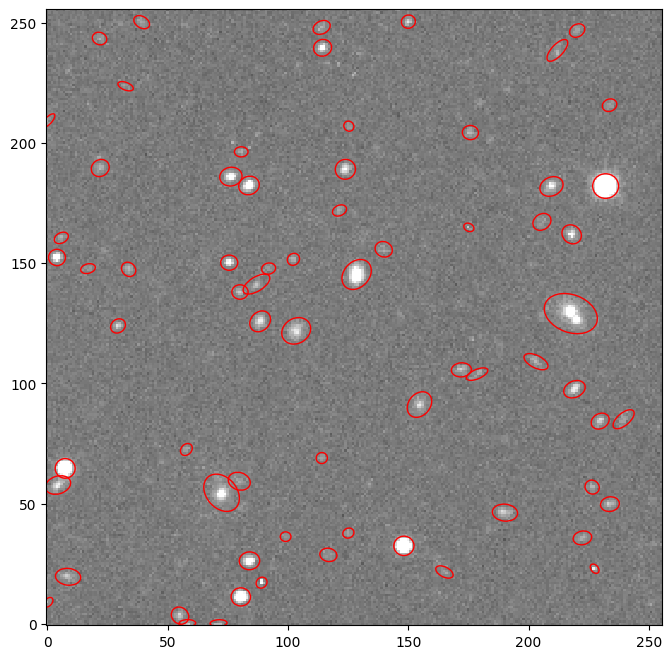

In [14]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]), width=6*objects['a'][i], height=6*objects['b'][i], angle=objects['theta'][i] * 100. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

plt.savefig('FITS-example-objects.png', bbox_inches='tight', facecolor='white')

objects has many other fields, giving information such as second moments, and peak pixel positions and values. They can be accessed by using objects.dtype.names

## Aperture photometry
Finally, we'll perform simple circular aperture photometry with a 3 pixel radius at the locations of the objects:

In [15]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err=bkg.globalrms, gain=1.0)

flux, fluxerr, and flag are all 1D arrays with one entry per object.

In [16]:
# show the first 10 objects results:
for i in range(10):
    print('object {:d}: flux = {:f} +/- {:f}'.format(i, flux[i], fluxerr[i]))

object 0: flux = 2249.159297 +/- 291.027802
object 1: flux = 3092.220430 +/- 291.592204
object 2: flux = 5949.868379 +/- 356.562003
object 3: flux = 1851.426582 +/- 295.028816
object 4: flux = 72736.386914 +/- 440.172206
object 5: flux = 3860.756152 +/- 352.163162
object 6: flux = 6418.913789 +/- 357.458973
object 7: flux = 2210.707656 +/- 350.791223
object 8: flux = 2741.607227 +/- 352.277746
object 9: flux = 20916.875566 +/- 376.966138
